<a href="https://colab.research.google.com/github/RekhaThota22/Customer-Segmentation-using-Kmeans/blob/main/Customer_Segmentation_using_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Import Libraries
**Why**: We start by importing the necessary libraries for data manipulation, visualization, and machine learning algorithms.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
import datetime as dt

## 2. Loading and understanding the data
**Why**: Before applying any algorith we need to know the data and features avaliable and check for missing values and invalid values

In [14]:
try :
  df = pd.read_excel('/content/Online Retail.xlsx')
  print("Data loaded succesfully")
except FileNotFoundError:
  print('Please download the dataset and place it in the working directory.')

# Viewing the basic info and the sample data
df.info()
df.sample(10)

Data loaded succesfully
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
380397,569789,48116,DOORMAT MULTICOLOUR STRIPE,2,2011-10-06 11:41:00,8.25,16924.0,United Kingdom
30236,538853,22966,GINGERBREAD MAN COOKIE CUTTER,3,2010-12-14 13:35:00,1.25,16805.0,United Kingdom
438708,574328,21485,RETROSPOT HEART HOT WATER BOTTLE,12,2011-11-04 09:05:00,4.95,13081.0,United Kingdom
106280,545320,22630,DOLLY GIRL LUNCH BOX,192,2011-03-01 14:47:00,1.65,14156.0,EIRE
410404,572103,37476,CONDIMENT TRAY 4 BOWLS AND 4 SPOONS,1,2011-10-20 15:57:00,9.95,17571.0,United Kingdom
314101,564562,85132C,CHARLIE AND LOLA FIGURES TINS,12,2011-08-26 09:58:00,1.95,15203.0,United Kingdom
482385,577473,82582,AREA PATROLLED METAL SIGN,1,2011-11-20 11:28:00,2.10,15919.0,United Kingdom
399876,571289,22992,REVOLVER WOODEN RULER,24,2011-10-16 15:27:00,1.95,15113.0,United Kingdom
230261,557129,84997B,CHILDRENS CUTLERY RETROSPOT RED,1,2011-06-16 19:59:00,4.15,17841.0,United Kingdom
529838,580754,22726,ALARM CLOCK BAKELIKE GREEN,18,2011-12-06 10:05:00,8.29,NaN,United Kingdom


 # 3.  Data Preprocessing:
The data is transaction if we cluster on this ,we are clustering reciets not customers.
To fix this we aggregate teh data to customer using he RFM frame work


*   **Recency** : How many days ago was their last purchase?
*   **Frequency** : How many times have they purchased?
*   **Monetary** : How much have they spent in total?

Finally we apply StandardScalar.


In [16]:
# 1. Removing the cancelled orders
df=df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

#2.Its clear that we have  a large dataset so we can go ahead and drop nulls
df.dropna(inplace = True)

#3. Calculating Total_price per row
df['Total_Amount'] = df['UnitPrice'] * df['Quantity']

#4. Build RFM Table
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days = 1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x:(snapshot_date -x.max()).days, # Recency
    'InvoiceNo' : 'nunique', # Frequency
    'Total_Amount' : 'sum' # Monetory
})
rfm.rename(columns ={'InvoiceDate' : 'Recency','InvoiceNo' : 'Frequency','Total_Amount' : 'Monetary'} , inplace = True)

#5.Feature Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns = rfm.columns, index = rfm.index)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


# 4.Exploratory Data Analysis (EDA)
**Why**: Presence of outliers result in the model performance, visualizing the data helps us to know the outliers.

Text(0.5, 1.0, 'Monetary')

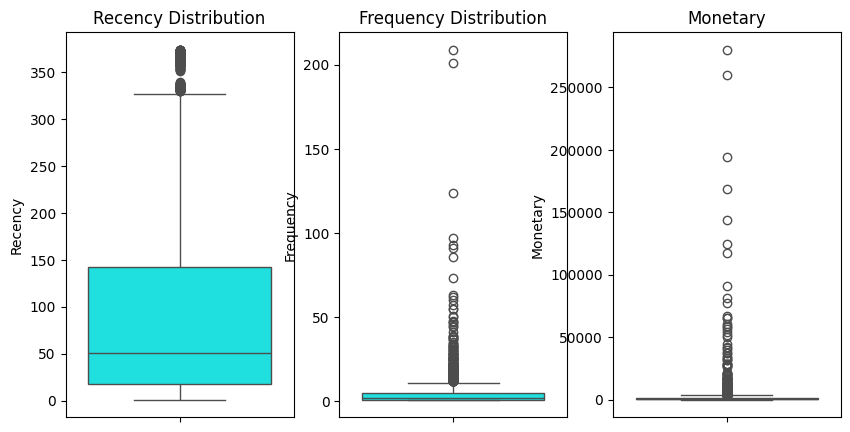

In [17]:
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
sns.boxplot( y = rfm['Recency'],color = 'cyan')
plt.title('Recency Distribution')

plt.subplot(1,3,2)
sns.boxplot( y = rfm['Frequency'],color = 'cyan')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
sns.boxplot( y = rfm['Monetary'],color = 'cyan')
plt.title('Monetary')

## 5. Optimal Cluster Selection (Elbow Method)
**Why** : K-means require us to manually enter he number of clusters ,We run the algorithm multiple times(1 to 10) and plot the Within_cluster sum of Squared.We check for the "elbow" --The point where another cluster guces the diminishing returns in the variance

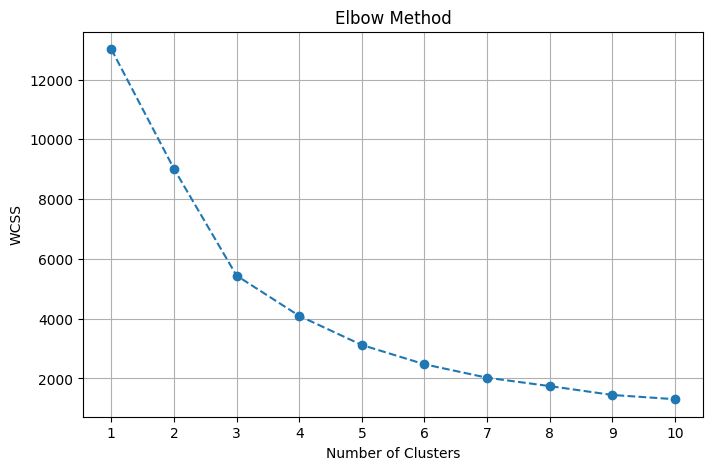

In [23]:
wcss =[]
k_range = range(1,11)
for k in k_range:
  kmeans = KMeans(n_clusters = k,
                  random_state = 42,
                  n_init = 10)
  kmeans.fit(rfm_scaled_df)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(k_range,wcss,marker = 'o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()


# 6.Apply K_means
**Why**: Looking at the elbow plot ,a bend typically occurs at k=3.We will group our dataset into 3 clusters i.e,3 primary customer profiles.

In [24]:
# Initialize and fit K-Means with optimal K
kmeans = KMeans(n_clusters = 3,random_state = 42,n_init = 10)
rfm['Cluster_KMeans'] = kmeans.fit_predict(rfm_scaled_df)

print('Kmeans Clustering completed')

Kmeans Clustering completed


# 7. Visualization of Clusters
**Why** : Scatterplot visualization allows us to verify if the clusters are logicallu seperated.We plot Recency against Monetory to see if the "high spend/low recency" seperated out clearly

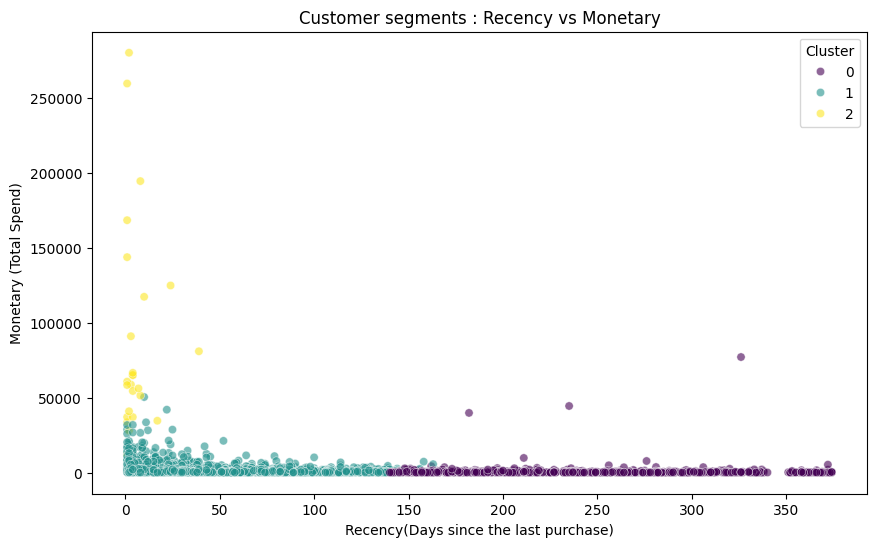

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'Recency' , y = 'Monetary', data= rfm,hue = 'Cluster_KMeans', palette = 'viridis',alpha = 0.6)
plt.title('Customer segments : Recency vs Monetary')
plt.xlabel('Recency(Days since the last purchase)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title = 'Cluster')
plt.show()

# 8.Applying DBScan
**Why**: k-means will assume all spherical clusters and there by sensitive to the outliers .DBScan identifies teh outliers and isolates the outliers as noise(label = -1).This is excellengt in retail for catching massive wholesale buyers who skew averages.

In [35]:
# eps = searcgh radius,
# min_samples = minimun density neede dto be clustered

dbscan= DBSCAN(eps = 0.8,min_samples = 10)

rfm['Cluster_DBSCAN'] = dbscan.fit_predict(rfm_scaled_df)

print('DBSCAN Cluster distribution (Note: -1 represents extreme outliers/noise):')
print(rfm['Cluster_DBSCAN'].value_counts())


DBSCAN Cluster distribution (Note: -1 represents extreme outliers/noise):
Cluster_DBSCAN
 0    4292
-1      46
Name: count, dtype: int64


# Performance Evaluation (Silhouette Score)¶
***Why**: The Silhouette Score measures cluster cohesion (how close points are to their own cluster) vs separation (how far they are from other clusters). It ranges from -1 to 1. A higher score means better-defined segmentation.

In [40]:
sil_score_kmeans = silhouette_score(rfm_scaled_df,rfm['Cluster_KMeans'])
print(f'Silhouette score for K_means for (k=3) : {sil_score_kmeans:.3}')

Silhouette score for K_means for (k=3) : 0.594


#10. Cluster Interpretation:
**Why**: Algorithms only provide mathematical labels(0,1,2).Its data scientist job to map these mathematical groups to actonable business strategies

In [51]:
# Calculating the mean of R,F,M for all clusters
cluster_summary = rfm.groupby('Cluster_KMeans').agg(
    {
        'Recency' : 'mean',
        'Frequency': 'mean',
        'Monetary' : ['mean','count']
    }
).round(2)

display(cluster_summary)
print('\n--- Standard Retail Interpretation Based on Averages ---')
print('• High Spend, High Freq, Low Recency -> VIP / Loyal Customers')
print('• Low Spend, Low Freq, High Recency -> Lost / Churned Customers')
print('• Average Spend, Average Freq, Med Recency -> Regular / At-Risk Customers')

Recency Frequency  Monetary      
                  mean      mean      mean count
Cluster_KMeans                                  
0               247.11      1.58    631.42  1082
1                41.45      4.67   1855.94  3230
2                 6.04     66.42  85904.35    26


--- Standard Retail Interpretation Based on Averages ---
• High Spend, High Freq, Low Recency -> VIP / Loyal Customers
• Low Spend, Low Freq, High Recency -> Lost / Churned Customers
• Average Spend, Average Freq, Med Recency -> Regular / At-Risk Customers
